# Network-Based Credit Risk Analysis with Copulas

## Core Question

> **Given a network of 1000 people with individual default probabilities and transaction relationships, how do we quantify:**
> 1. Who is individually risky?
> 2. Who is dangerous to others (systemic)?
> 3. Who is vulnerable to others (contagion)?
> 4. What is the portfolio tail risk accounting for dependencies?

## How It Works

```
INDIVIDUAL FEATURES           TRANSACTION NETWORK          DEPENDENCY MODEL
  (income, debt, etc.)         (who pays whom)             (copula)
         ↓                           ↓                          ↓
    Base PD Model          Graph + Correlation Matrix     Joint Default Probabilities
         ↓                           ↓                          ↓
    Marginal P(Default)         P(D_i | D_j)              Portfolio VaR, ES
         └───────────────────────────┴──────────────────────────┘
                                     ↓
                           COMPOSITE RISK METRICS
                    (individual, group, portfolio levels)
```

---
## Part 1: Setup and Data Generation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Import project modules
from src.data_generator import generate_network, get_summary_stats
from src.graph_features import TransactionGraph, get_neighbor_risk_features
from src.copula_model import CopulaDefaultModel, compare_copulas
from src.risk_metrics import RiskAnalyzer

np.random.seed(42)
print("Modules loaded successfully!")

Modules loaded successfully!


### Generate Network: 1000 Persons, 3 Cities

| City | Population | Character | Base Risk |
|------|------------|-----------|----------|
| Alpha | 400 | Financial hub | Low |
| Beta | 350 | Industrial | Medium |
| Gamma | 250 | Concentrated | High |

Embedded structures:
- **4 high-risk groups** (10-20 people each, tightly connected)
- **15 bridge individuals** (low risk but connect cities)

In [2]:
# Generate the network
persons, transactions = generate_network(
    n_high_risk_groups=4,
    group_size_range=(10, 20),
    n_bridges=15,
    seed=42
)

# Summary statistics
stats = get_summary_stats(persons, transactions)

print("=" * 50)
print("NETWORK SUMMARY")
print("=" * 50)
print(f"\nTotal persons: {stats['n_persons']}")
print(f"Total transactions: {stats['n_transactions']}")

print("\n--- By City ---")
for city, count in stats['persons_per_city'].items():
    avg_pd = stats['pd_by_city'][city]
    print(f"  {city}: {count} persons, avg PD = {avg_pd:.2%}")

print("\n--- Risk Archetypes ---")
for archetype, count in stats['risk_archetype_counts'].items():
    avg_pd = stats['pd_by_archetype'][archetype]
    print(f"  {archetype}: {count} persons ({count/len(persons):.0%}), avg PD = {avg_pd:.2%}")

print(f"\n--- Special Groups ---")
print(f"  High-risk groups: {stats['n_high_risk_groups']}")
print(f"  High-risk group members: {stats['n_high_risk_group_members']}")
print(f"  Bridge individuals: {stats['n_bridges']}")

print(f"\n--- Transaction Patterns ---")
print(f"  Within-city: {stats['within_city_tx_pct']:.1%}")
print(f"  Within-group: {stats['within_group_tx_pct']:.1%}")

NETWORK SUMMARY

Total persons: 1000
Total transactions: 8000

--- By City ---
  Alpha: 400 persons, avg PD = 8.16%
  Beta: 350 persons, avg PD = 13.66%
  Gamma: 250 persons, avg PD = 23.16%

--- Risk Archetypes ---
  low: 700 persons (70%), avg PD = 5.23%
  medium: 200 persons (20%), avg PD = 25.19%
  high: 100 persons (10%), avg PD = 51.35%

--- Special Groups ---
  High-risk groups: 4
  High-risk group members: 68
  Bridge individuals: 15

--- Transaction Patterns ---
  Within-city: 86.0%
  Within-group: 3.2%


---
## Part 2: Build Transaction Graph

In [3]:
# Build the graph
graph = TransactionGraph(transactions, persons)

# Network statistics
net_stats = graph.get_network_stats()
print("=" * 50)
print("NETWORK STATISTICS")
print("=" * 50)
print(f"Nodes: {net_stats.n_nodes}")
print(f"Edges: {net_stats.n_edges}")
print(f"Density: {net_stats.density:.4f}")
print(f"Avg degree: {net_stats.avg_degree:.1f}")
print(f"Avg clustering: {net_stats.avg_clustering:.3f}")
print(f"Connected components: {net_stats.n_components}")

NETWORK STATISTICS
Nodes: 1000
Edges: 7792
Density: 0.0156
Avg degree: 15.6
Avg clustering: 0.036
Connected components: 1


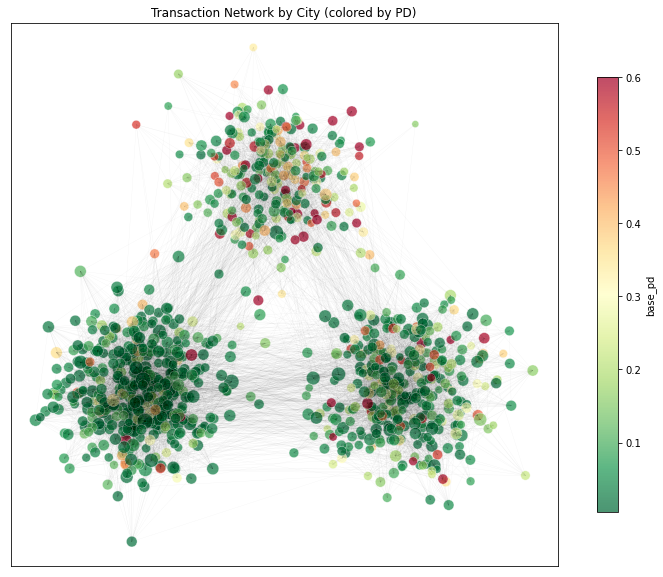

In [4]:
# Visualize the network by city
fig = graph.plot_network(
    color_by='base_pd',
    size_by='degree',
    layout='city',
    title='Transaction Network by City (colored by PD)',
    figsize=(14, 10),
    edge_alpha=0.05
)
plt.show()

---
## Part 3: Derive Correlation Matrix from Graph

The key insight: **Graph tells us WHO is connected, correlation tells us HOW STRONGLY their defaults are linked.**

Correlation increases with:
- Transaction volume between individuals
- Same city membership
- Same high-risk group membership

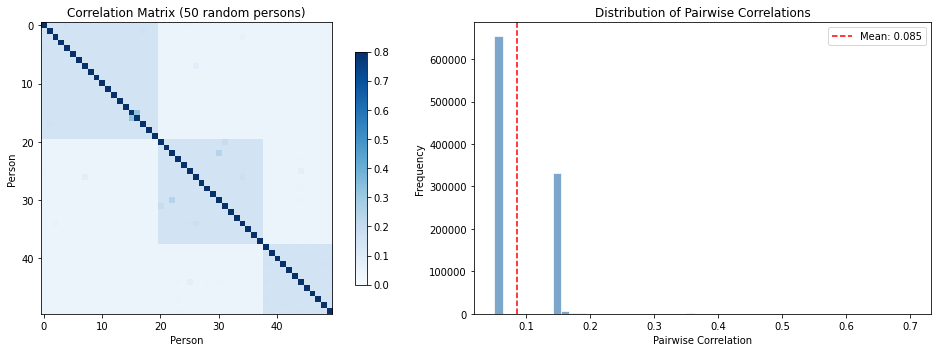

Average correlation: 0.0850
Max correlation: 0.7000


In [5]:
# Derive correlation matrix from network
correlation_matrix = graph.get_correlation_matrix(
    base_corr=0.05,
    max_corr=0.6,
    same_city_boost=0.1,
    same_group_boost=0.2
)

# Visualize correlation structure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation matrix heatmap (sampled)
n = len(persons)
sample_idx = np.random.choice(n, min(50, n), replace=False)
sample_idx.sort()
sample_corr = correlation_matrix[np.ix_(sample_idx, sample_idx)]

im = axes[0].imshow(sample_corr, cmap='Blues', vmin=0, vmax=0.8)
axes[0].set_title('Correlation Matrix (50 random persons)')
axes[0].set_xlabel('Person')
axes[0].set_ylabel('Person')
plt.colorbar(im, ax=axes[0], shrink=0.8)

# Distribution of correlations
off_diag = correlation_matrix[~np.eye(n, dtype=bool)]
axes[1].hist(off_diag, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
axes[1].axvline(off_diag.mean(), color='red', linestyle='--', label=f'Mean: {off_diag.mean():.3f}')
axes[1].set_xlabel('Pairwise Correlation')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Pairwise Correlations')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Average correlation: {off_diag.mean():.4f}")
print(f"Max correlation: {off_diag.max():.4f}")

---
## Part 4: Fit Copula Model

We use the **Clayton copula** because:
- It captures **lower tail dependence** (defaults cluster in stress)
- Real default events are not symmetric - bad times are correlated, good times less so
- Formula: $C(u, v; \theta) = (u^{-\theta} + v^{-\theta} - 1)^{-1/\theta}$

In [6]:
# Fit Clayton copula
marginal_pds = persons['base_pd'].values

copula = CopulaDefaultModel('clayton')
copula.fit(marginal_pds, correlation_matrix)

print("=" * 50)
print("COPULA MODEL")
print("=" * 50)
summary = copula.summary()
for key, value in summary.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

COPULA MODEL
copula_type: clayton
n_persons: 1000
theta: 0.1146
nu: None
avg_correlation: 0.0850
avg_marginal_pd: 0.1383
tail_dependence: 0.0024


In [7]:
# Compare copula types
print("\n=== Copula Comparison ===")
comparison = compare_copulas(marginal_pds, correlation_matrix)

comparison_df = pd.DataFrame(comparison).T
comparison_df.index.name = 'copula_type'
print(comparison_df.round(4).to_string())


=== Copula Comparison ===


              theta  tail_dependence  sim_default_rate  sim_correlation
copula_type                                                            
gaussian     0.0850           0.0000            0.1363           0.0164
student_t    0.0850           0.0952            0.1422           0.1385
clayton      0.1146           0.0024            0.1407           0.0467
gumbel       1.0573           0.0737            0.1232           0.1069


### Conditional Default Probabilities

The KEY metric: **P(D_i | D_j)** - How much does person i's default probability increase if person j defaults?

$$P(D_i | D_j) = \frac{C(p_i, p_j)}{p_j}$$

This is always $\geq p_i$ for positive dependence.

In [8]:
# Sample conditional probabilities
print("=" * 50)
print("CONTAGION EFFECT: P(D_i | D_j) vs P(D_i)")
print("=" * 50)

# Pick some connected pairs
print("\nSample connected pairs:")
for i in [0, 10, 50, 100]:
    # Find a neighbor
    neighbors = np.where(graph.adj_binary[i] > 0)[0]
    if len(neighbors) > 0:
        j = neighbors[0]
        marginal_i = marginal_pds[i]
        cond_i_given_j = copula.conditional_default_probability(i, j)
        uplift = cond_i_given_j - marginal_i
        print(f"  P(D_{i}|D_{j}) = {cond_i_given_j:.4f}, "
              f"marginal = {marginal_i:.4f}, "
              f"uplift = +{uplift:.4f} ({uplift/marginal_i*100:.1f}%)")

CONTAGION EFFECT: P(D_i | D_j) vs P(D_i)

Sample connected pairs:
  P(D_0|D_48) = 0.0847, marginal = 0.0491, uplift = +0.0356 (72.5%)
  P(D_10|D_6) = 0.0533, marginal = 0.0359, uplift = +0.0174 (48.5%)
  P(D_50|D_8) = 0.0568, marginal = 0.0351, uplift = +0.0217 (61.9%)
  P(D_100|D_40) = 0.0443, marginal = 0.0201, uplift = +0.0242 (120.3%)


---
## Part 5: Risk Analysis

Three levels of analysis:
1. **Individual**: Per-person risk scores and rankings
2. **Group**: High-risk cluster analysis
3. **Portfolio**: VaR, ES, concentration metrics

In [9]:
# Initialize risk analyzer
analyzer = RiskAnalyzer(copula, graph, persons, lgd=0.45)

### 5.1 Individual Risk Metrics

For each person, we compute:
- **Marginal PD**: Base probability of default
- **Contagion Vulnerability**: How much PD increases if neighbors default
- **Systemic Importance**: How much others' PD increases if this person defaults
- **Network Exposure**: Weighted average neighbor PD
- **Composite Risk Score**: Weighted combination of above

In [10]:
# Compute individual risk metrics
individual_risks = analyzer.compute_individual_risks()

print("=" * 50)
print("INDIVIDUAL RISK ANALYSIS")
print("=" * 50)

print("\nRisk Tier Distribution:")
tier_counts = individual_risks['risk_tier'].value_counts()
for tier in ['low', 'medium', 'high', 'critical']:
    count = tier_counts.get(tier, 0)
    print(f"  {tier.upper()}: {count} ({count/len(persons):.0%})")

INDIVIDUAL RISK ANALYSIS

Risk Tier Distribution:
  LOW: 601 (60%)
  MEDIUM: 0 (0%)
  HIGH: 0 (0%)
  CRITICAL: 0 (0%)


In [11]:
# Top 15 riskiest individuals
print("\nTop 15 Riskiest Individuals:")
top_risks = analyzer.get_top_risks(15)
display_cols = ['person_id', 'city_name', 'risk_archetype', 'marginal_pd', 
                'contagion_vulnerability', 'systemic_importance', 
                'composite_risk_score', 'risk_tier', 'in_high_risk_group']
print(top_risks[display_cols].to_string(index=False))


Top 15 Riskiest Individuals:
 person_id city_name risk_archetype  marginal_pd  contagion_vulnerability  systemic_importance  composite_risk_score risk_tier  in_high_risk_group
       912     Gamma           high       0.6000                   0.0051               0.0082                0.7591       cri                True
       812     Gamma           high       0.6000                   0.0051               0.0082                0.7255       cri                True
       936     Gamma           high       0.5675                   0.0055               0.0092                0.7254       cri                True
       821     Gamma           high       0.6000                   0.0048               0.0083                0.7105       cri                True
       777     Gamma           high       0.6000                   0.0049               0.0082                0.7028       cri                True
       795     Gamma           high       0.6000                   0.0051               

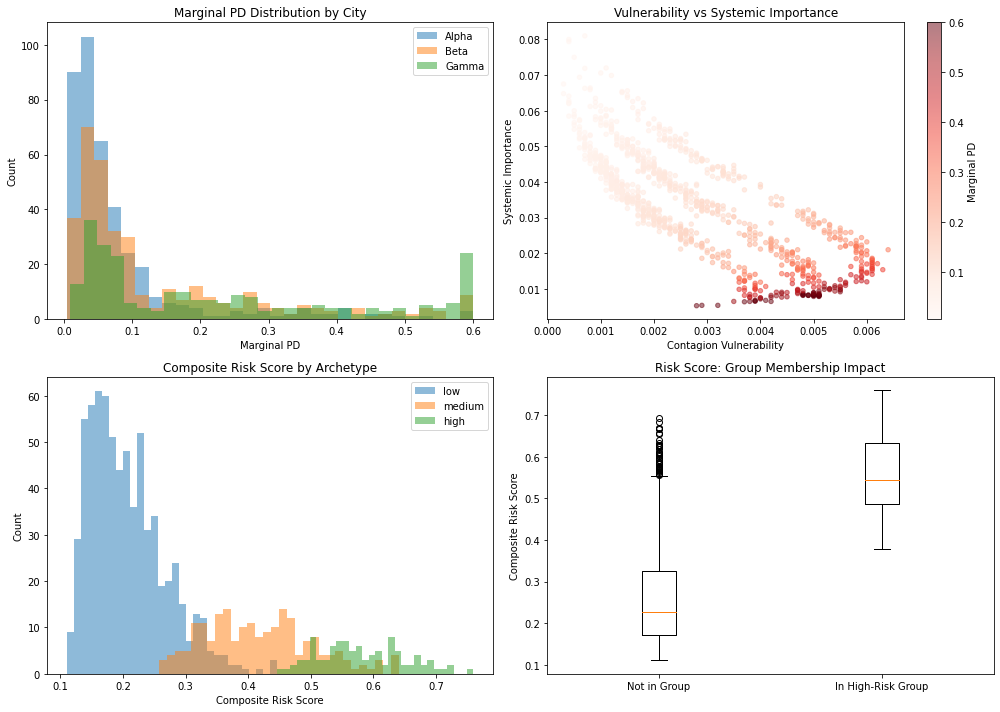

In [12]:
# Visualize risk components
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Marginal PD by city
ax = axes[0, 0]
for city in ['Alpha', 'Beta', 'Gamma']:
    city_data = individual_risks[individual_risks['city_name'] == city]['marginal_pd']
    ax.hist(city_data, bins=30, alpha=0.5, label=city)
ax.set_xlabel('Marginal PD')
ax.set_ylabel('Count')
ax.set_title('Marginal PD Distribution by City')
ax.legend()

# 2. Vulnerability vs Systemic Importance
ax = axes[0, 1]
scatter = ax.scatter(
    individual_risks['contagion_vulnerability'],
    individual_risks['systemic_importance'],
    c=individual_risks['marginal_pd'],
    cmap='Reds', alpha=0.5, s=20
)
ax.set_xlabel('Contagion Vulnerability')
ax.set_ylabel('Systemic Importance')
ax.set_title('Vulnerability vs Systemic Importance')
plt.colorbar(scatter, ax=ax, label='Marginal PD')

# 3. Composite score distribution by archetype
ax = axes[1, 0]
for archetype in ['low', 'medium', 'high']:
    data = individual_risks[individual_risks['risk_archetype'] == archetype]['composite_risk_score']
    ax.hist(data, bins=30, alpha=0.5, label=archetype)
ax.set_xlabel('Composite Risk Score')
ax.set_ylabel('Count')
ax.set_title('Composite Risk Score by Archetype')
ax.legend()

# 4. Group membership impact
ax = axes[1, 1]
in_group = individual_risks[individual_risks['in_high_risk_group']]['composite_risk_score']
not_in_group = individual_risks[~individual_risks['in_high_risk_group']]['composite_risk_score']
ax.boxplot([not_in_group, in_group], labels=['Not in Group', 'In High-Risk Group'])
ax.set_ylabel('Composite Risk Score')
ax.set_title('Risk Score: Group Membership Impact')

plt.tight_layout()
plt.show()

### 5.2 Group Risk Metrics

Analyze the 4 high-risk groups embedded in the network.

In [13]:
print("=" * 50)
print("GROUP RISK ANALYSIS")
print("=" * 50)

group_summary = analyzer.get_group_summary()
print("\nHigh-Risk Group Summary:")
print(group_summary.to_string(index=False))

GROUP RISK ANALYSIS

High-Risk Group Summary:
 group_id  size  avg_pd  max_pd  internal_correlation  expected_loss
        1    19  0.4033     0.6                0.3576         3.4483
        3    18  0.4111     0.6                0.3558         3.3297
        0    16  0.4266     0.6                0.3555         3.0714
        2    15  0.3312     0.6                0.3629         2.2358


### 5.3 Portfolio Risk Metrics

Monte Carlo simulation with copula-correlated defaults.

In [14]:
print("=" * 50)
print("PORTFOLIO RISK ANALYSIS")
print("=" * 50)

portfolio_summary = analyzer.portfolio_summary()
print("\nPortfolio Metrics:")
print(portfolio_summary.to_string(index=False))

PORTFOLIO RISK ANALYSIS



Portfolio Metrics:
                  metric    value
           Expected Loss  62.2040
                 VaR 95% 122.4000
                 VaR 99% 163.3500
  Expected Shortfall 95% 146.1166
  Expected Shortfall 99% 184.5847
     Default Correlation   0.0567
     Concentration Index   0.0010
Tail Risk Ratio (ES/VaR)   1.1938


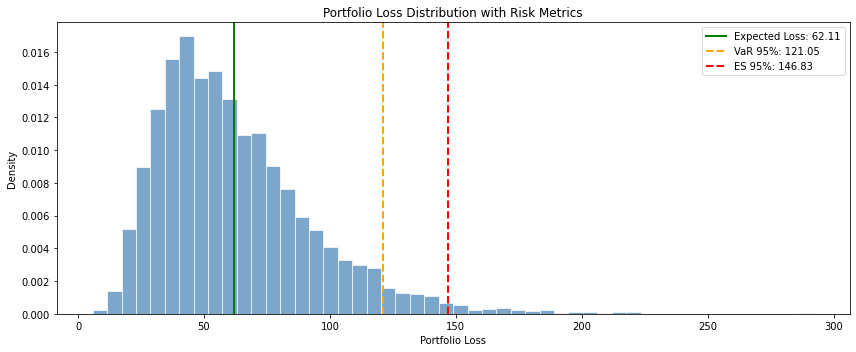

In [15]:
# Visualize loss distribution
losses = analyzer.get_loss_distribution(n_simulations=10000)
portfolio_metrics = analyzer.compute_portfolio_risks(n_simulations=10000)

fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(losses, bins=50, color='steelblue', alpha=0.7, edgecolor='white', density=True)
ax.axvline(portfolio_metrics.expected_loss, color='green', linestyle='-', 
           linewidth=2, label=f'Expected Loss: {portfolio_metrics.expected_loss:.2f}')
ax.axvline(portfolio_metrics.var_95, color='orange', linestyle='--', 
           linewidth=2, label=f'VaR 95%: {portfolio_metrics.var_95:.2f}')
ax.axvline(portfolio_metrics.es_95, color='red', linestyle='--', 
           linewidth=2, label=f'ES 95%: {portfolio_metrics.es_95:.2f}')

ax.set_xlabel('Portfolio Loss')
ax.set_ylabel('Density')
ax.set_title('Portfolio Loss Distribution with Risk Metrics')
ax.legend()

plt.tight_layout()
plt.show()

---
## Part 6: Stress Testing

What happens under stressed conditions?
- Double all PDs
- Increase correlations by 20%

In [16]:
print("=" * 50)
print("STRESS TEST RESULTS")
print("=" * 50)

stress_results = analyzer.stress_test(pd_multiplier=2.0, correlation_boost=0.2)

print("\nBase vs Stressed Comparison:")
print("-" * 40)
print(f"{'Metric':<20} {'Base':>10} {'Stressed':>10} {'Change':>10}")
print("-" * 40)
for metric in ['expected_loss', 'var_95', 'es_95']:
    base = stress_results['base'][metric]
    stressed = stress_results['stressed'][metric]
    change = stress_results['change'][metric]
    print(f"{metric:<20} {base:>10.2f} {stressed:>10.2f} {change:>+10.1%}")

STRESS TEST RESULTS



Base vs Stressed Comparison:
----------------------------------------
Metric                     Base   Stressed     Change
----------------------------------------
expected_loss             62.81     120.42     +91.7%
var_95                   124.67     182.72     +46.6%
es_95                    150.40     205.06     +36.3%


---
## Part 7: Key Insights Summary

In [17]:
print("=" * 60)
print("KEY INSIGHTS")
print("=" * 60)

print(f"""
1. NETWORK STRUCTURE
   - {len(persons)} persons across 3 cities with {net_stats.n_edges} transaction links
   - Average {net_stats.avg_degree:.1f} connections per person
   - {stats['n_high_risk_groups']} high-risk groups with {stats['n_high_risk_group_members']} members

2. DEPENDENCY MODELING
   - Clayton copula captures lower tail dependence (defaults cluster)
   - Tail dependence coefficient: {copula.tail_dependence():.3f}
   - Average correlation: {off_diag.mean():.3f}

3. INDIVIDUAL RISK
   - {tier_counts.get('critical', 0)} critical-risk individuals (top 5%)
   - {tier_counts.get('high', 0)} high-risk individuals (top 15%)
   - High-risk groups show elevated composite scores

4. PORTFOLIO RISK
   - Expected Loss: {portfolio_metrics.expected_loss:.2f}
   - VaR 95%: {portfolio_metrics.var_95:.2f}
   - ES 95%: {portfolio_metrics.es_95:.2f}
   - Tail ratio (ES/VaR): {portfolio_metrics.tail_risk_ratio:.2f}

5. STRESS SENSITIVITY
   - 2x PD + 20% correlation boost
   - Expected Loss increases {stress_results['change']['expected_loss']:.0%}
   - VaR 95% increases {stress_results['change']['var_95']:.0%}
   - ES 95% increases {stress_results['change']['es_95']:.0%}
""")

KEY INSIGHTS

1. NETWORK STRUCTURE
   - 1000 persons across 3 cities with 7792 transaction links
   - Average 15.6 connections per person
   - 4 high-risk groups with 68 members

2. DEPENDENCY MODELING
   - Clayton copula captures lower tail dependence (defaults cluster)
   - Tail dependence coefficient: 0.002
   - Average correlation: 0.085

3. INDIVIDUAL RISK
   - 0 critical-risk individuals (top 5%)
   - 0 high-risk individuals (top 15%)
   - High-risk groups show elevated composite scores

4. PORTFOLIO RISK
   - Expected Loss: 62.11
   - VaR 95%: 121.05
   - ES 95%: 146.83
   - Tail ratio (ES/VaR): 1.21

5. STRESS SENSITIVITY
   - 2x PD + 20% correlation boost
   - Expected Loss increases 92%
   - VaR 95% increases 47%
   - ES 95% increases 36%



---
## Appendix: How the Pieces Connect

```
┌─────────────────────────────────────────────────────────────────┐
│                     INDIVIDUAL LEVEL                            │
│  Features (age, income, DTI, etc.)                              │
│       ↓                                                         │
│  Logistic Model → base_pd (marginal probability)                │
│       ↓                                                         │
│  + Graph Features (degree, PageRank, clustering)                │
│       ↓                                                         │
│  Network Exposure = Σ(neighbor_pd × edge_weight)                │
└─────────────────────────────────────────────────────────────────┘
                              ↓
┌─────────────────────────────────────────────────────────────────┐
│                     DEPENDENCY STRUCTURE                        │
│  Transaction Graph + Geography → Correlation Matrix             │
│       ↓                                                         │
│  Clayton Copula fitted on (pd_vector, corr_matrix)              │
│       ↓                                                         │
│  Joint P(D_i ∩ D_j), Conditional P(D_i | D_j)                   │
│       ↓                                                         │
│  Contagion Vulnerability, Systemic Importance                   │
└─────────────────────────────────────────────────────────────────┘
                              ↓
┌─────────────────────────────────────────────────────────────────┐
│                     RISK METRICS                                │
│  Individual:                                                    │
│    - Composite Risk Score = weighted(PD, network, contagion)    │
│    - Risk Tier: low/medium/high/critical                        │
│                                                                 │
│  Group:                                                         │
│    - Internal correlation, joint default probability            │
│    - Expected group loss                                        │
│                                                                 │
│  Portfolio:                                                     │
│    - Monte Carlo → Loss distribution                            │
│    - VaR, ES, concentration metrics                             │
└─────────────────────────────────────────────────────────────────┘
```